<a href="https://colab.research.google.com/github/Chethang0wda215/PedictiveAanalysisML/blob/main/DATask2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving housing.csv to housing.csv


In [ ]:
import pandas as pd

df = pd.read_csv("/content/housing.csv")  # adjust path if needed
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [ ]:
df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)


/tmp/ipykernel_609/4187285536.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)


In [ ]:
df.isnull().sum()


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [ ]:
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']


In [ ]:
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

In [ ]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

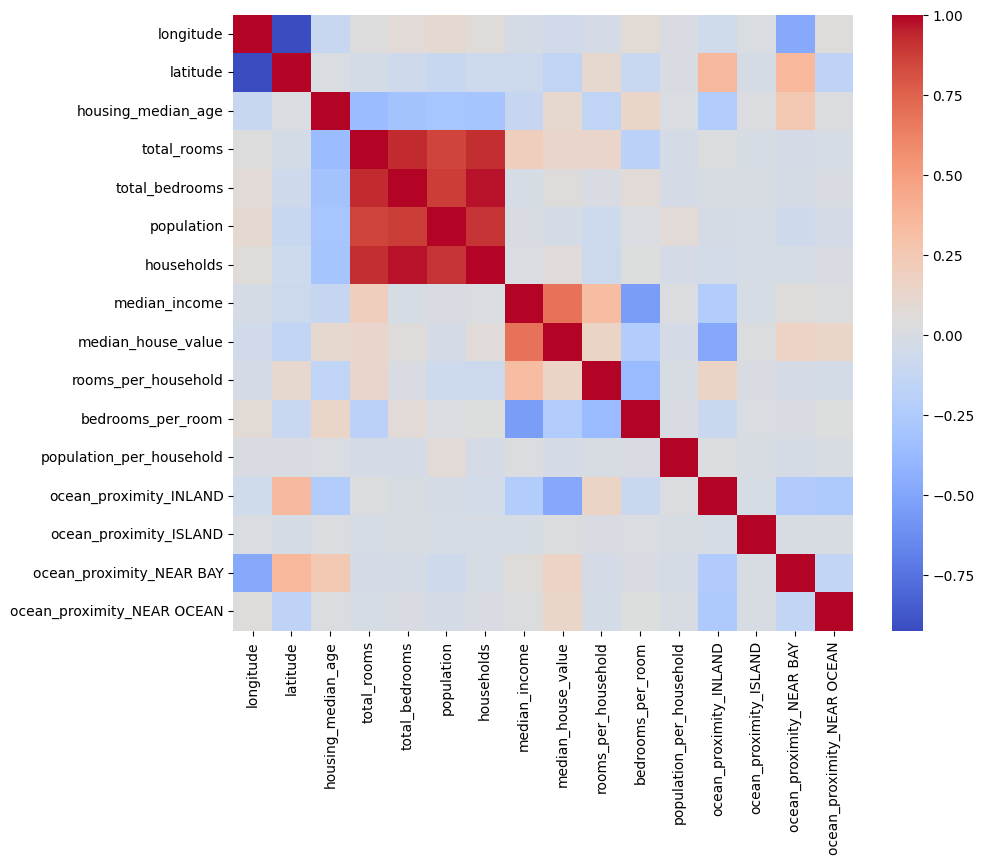

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

In [ ]:
corr['median_house_value'].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688075
ocean_proximity_NEAR BAY,0.160284
rooms_per_household,0.151948
ocean_proximity_NEAR OCEAN,0.141862
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049457
ocean_proximity_ISLAND,0.023416


In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def evaluate(y_test, y_pred, name):
    print(f"--- {name} ---")
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2 Score:", r2_score(y_test, y_pred))
    print()

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")

--- Linear Regression ---
RMSE: 72668.53837868226
R2 Score: 0.5970176824350761

--- Random Forest ---
RMSE: 50330.947163568584
R2 Score: 0.8066859824340856



In [ ]:
import pandas as pd

importance = rf.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importance, index=feature_names).sort_values(ascending=False)
print(feat_imp.head(10))


median_income               0.481661
ocean_proximity_INLAND      0.137520
population_per_household    0.121586
longitude                   0.057939
latitude                    0.056532
housing_median_age          0.044267
rooms_per_household         0.025967
bedrooms_per_room           0.024248
total_rooms                 0.012499
total_bedrooms              0.012137
dtype: float64


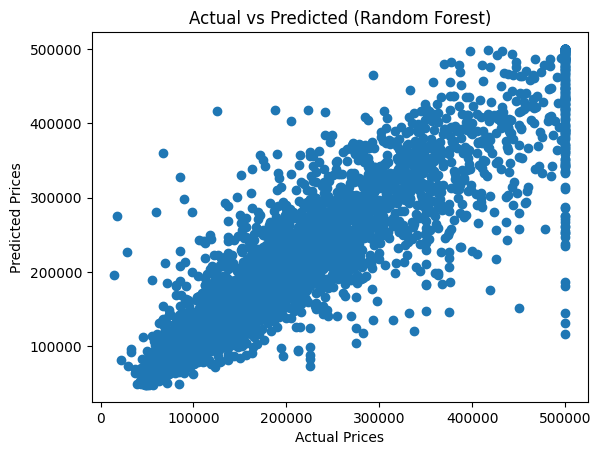

In [ ]:
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

In [ ]:
# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20]
}

grid = GridSearchCV(RandomForestRegressor(), param_grid, cv=3)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 20, 'n_estimators': 100}


In [ ]:
# Train Final Model with Best Params
from sklearn.ensemble import RandomForestRegressor

final_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    random_state=42
)

final_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, random_state=42)

In [ ]:
y_pred_final = final_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2 = r2_score(y_test, y_pred_final)

print("Final Model RMSE:", rmse)
print("Final Model R2 Score:", r2)

Final Model RMSE: 50427.69107558987
Final Model R2 Score: 0.8059421089567931


In [ ]:
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))
print("Random Forest (default) R2:", r2_score(y_test, y_pred_rf))
print("Tuned Random Forest R2:", r2)

Linear Regression R2: 0.5970176824350761
Random Forest (default) R2: 0.8066859824340856
Tuned Random Forest R2: 0.8059421089567931


In [ ]:
import pandas as pd

importances = final_model.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)
print(feat_imp.head(10))


median_income               0.483195
ocean_proximity_INLAND      0.138113
population_per_household    0.121667
longitude                   0.057604
latitude                    0.056267
housing_median_age          0.044026
rooms_per_household         0.025547
bedrooms_per_room           0.024000
total_rooms                 0.012080
total_bedrooms              0.012065
dtype: float64


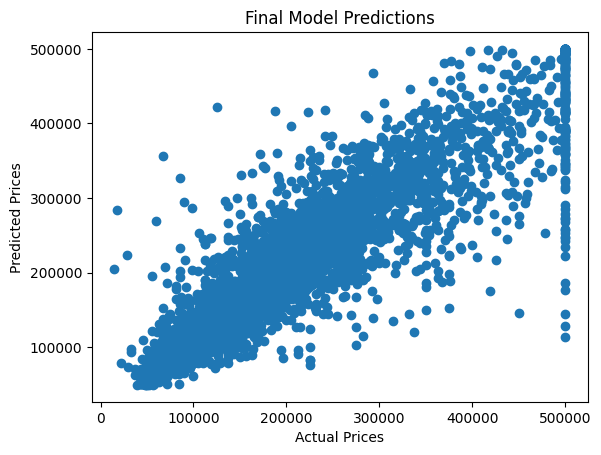

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_final)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Final Model Predictions")
plt.show()